In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import ast
from collections import Counter
import re

In [57]:
df = pd.read_csv("crawl_data\Data.csv")
df

,title,content,labels,url
0,Con trai ông Bùi Thành Nhơn làm Chủ tịch Novaland,Hội đồng quản trị (HĐQT) Tập đoànNovaland(NVL)...,['Kinh tế'],https://vnexpress.net/con-trai-ong-bui-thanh-n...
1,"Vingroup báo lãi tăng 2,5 lần","Theo báo cáo tài chính quý I, Vingroup ghi nhậ...",['Kinh tế'],https://vnexpress.net/vingroup-bao-lai-tang-2-...
2,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục,Khảo sát công bố ngày 10/4 của Đại học Michiga...,['Kinh tế'],https://vnexpress.net/niem-tin-tieu-dung-cua-n...
3,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...,"Ngày 4/5, Phó thủ tướng Hồ Quốc Dũng chủ trì c...",['Kinh tế'],https://vnexpress.net/pho-thu-tuong-yeu-cau-da...
4,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă...","Ngày 15/5, Liên đoàn Thương mại và Công nghiệp...",['Kinh tế'],https://vnexpress.net/tp-hcm-ha-noi-tiep-tuc-k...
...,...,...,...,...
6238,Lời khai 'nhiều mâu thuẫn' của kẻ nổ súng Bùi ...,"Chiều 13/5, TAND tỉnh Quảng Ninh xét hỏi Bùi Đ...",['Chính trị - Pháp luật'],https://vnexpress.net/loi-khai-nhieu-mau-thuan...
6239,23 dự án bất động sản ở Hà Nội bị Thanh tra Ch...,Thông tin được Thanh tra Chính phủ nêu trong t...,['Chính trị - Pháp luật'],https://vnexpress.net/23-du-an-bat-dong-san-o-...
6240,Công an làm việc với chủ nhà cầm dao dọa chém ...,"Ngày 28/4, Công an phường Dĩ An, TP HCM đã làm...",['Chính trị - Pháp luật'],https://vnexpress.net/cong-an-lam-viec-voi-chu...
6241,Những hình phạt tiền khiến người vi phạm e sợ ...,Bộ Luật Hình sự đang được Bộ Công an xây dựng ...,['Chính trị - Pháp luật'],https://vnexpress.net/nhung-hinh-phat-tien-khi...


In [58]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6243 entries, 0 to 6242
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   title    6242 non-null   str  
 1   content  6243 non-null   str  
 2   labels   6243 non-null   str  
 3   url      6243 non-null   str  
dtypes: str(4)
memory usage: 195.2 KB


In [59]:
print(f"số dữ liệu bị trùng lặp: {df.duplicated().sum()}")

số dữ liệu bị trùng lặp: 0


In [60]:
# xử lý nhãn 
df['labels'] = df['labels'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["labels"]

0                     [Kinh tế]
1                     [Kinh tế]
2                     [Kinh tế]
3                     [Kinh tế]
4                     [Kinh tế]
                 ...           
6238    [Chính trị - Pháp luật]
6239    [Chính trị - Pháp luật]
6240    [Chính trị - Pháp luật]
6241    [Chính trị - Pháp luật]
6242    [Chính trị - Pháp luật]
Name: labels, Length: 6243, dtype: object

In [61]:
def clean_text(text):
    
    text = str(text)

    # xóa xuống dòng
    text = text.replace("\n", " ")

    # xóa nhiều khoảng trắng
    text = re.sub(r"\s+", " ", text)

    return text.strip()

df["title"] = df["title"].apply(clean_text)
df["content"] = df["content"].apply(clean_text)

In [62]:
df["text"] = (
    df["title"].astype(str)
    + " [SEP] "
    + df["content"].astype(str)
)
df

,title,content,labels,url,text
0,Con trai ông Bùi Thành Nhơn làm Chủ tịch Novaland,Hội đồng quản trị (HĐQT) Tập đoànNovaland(NVL)...,[Kinh tế],https://vnexpress.net/con-trai-ong-bui-thanh-n...,Con trai ông Bùi Thành Nhơn làm Chủ tịch Noval...
1,"Vingroup báo lãi tăng 2,5 lần","Theo báo cáo tài chính quý I, Vingroup ghi nhậ...",[Kinh tế],https://vnexpress.net/vingroup-bao-lai-tang-2-...,"Vingroup báo lãi tăng 2,5 lần [SEP] Theo báo c..."
2,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục,Khảo sát công bố ngày 10/4 của Đại học Michiga...,[Kinh tế],https://vnexpress.net/niem-tin-tieu-dung-cua-n...,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục [S...
3,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...,"Ngày 4/5, Phó thủ tướng Hồ Quốc Dũng chủ trì c...",[Kinh tế],https://vnexpress.net/pho-thu-tuong-yeu-cau-da...,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...
4,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă...","Ngày 15/5, Liên đoàn Thương mại và Công nghiệp...",[Kinh tế],https://vnexpress.net/tp-hcm-ha-noi-tiep-tuc-k...,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă..."
...,...,...,...,...,...
6238,Lời khai 'nhiều mâu thuẫn' của kẻ nổ súng Bùi ...,"Chiều 13/5, TAND tỉnh Quảng Ninh xét hỏi Bùi Đ...",[Chính trị - Pháp luật],https://vnexpress.net/loi-khai-nhieu-mau-thuan...,Lời khai 'nhiều mâu thuẫn' của kẻ nổ súng Bùi ...
6239,23 dự án bất động sản ở Hà Nội bị Thanh tra Ch...,Thông tin được Thanh tra Chính phủ nêu trong t...,[Chính trị - Pháp luật],https://vnexpress.net/23-du-an-bat-dong-san-o-...,23 dự án bất động sản ở Hà Nội bị Thanh tra Ch...
6240,Công an làm việc với chủ nhà cầm dao dọa chém ...,"Ngày 28/4, Công an phường Dĩ An, TP HCM đã làm...",[Chính trị - Pháp luật],https://vnexpress.net/cong-an-lam-viec-voi-chu...,Công an làm việc với chủ nhà cầm dao dọa chém ...
6241,Những hình phạt tiền khiến người vi phạm e sợ ...,Bộ Luật Hình sự đang được Bộ Công an xây dựng ...,[Chính trị - Pháp luật],https://vnexpress.net/nhung-hinh-phat-tien-khi...,Những hình phạt tiền khiến người vi phạm e sợ ...


                    Label  Count
0                 Kinh tế   1261
9                      Xe    906
2    Khoa học - Công nghệ    898
3                Thế giới    603
1                 Nhà đất    551
7                Giải trí    547
6                Thể thao    510
8   Chính trị - Pháp luật    490
4                Sức khỏe    487
10                Du lịch    451
5                Giáo dục    389


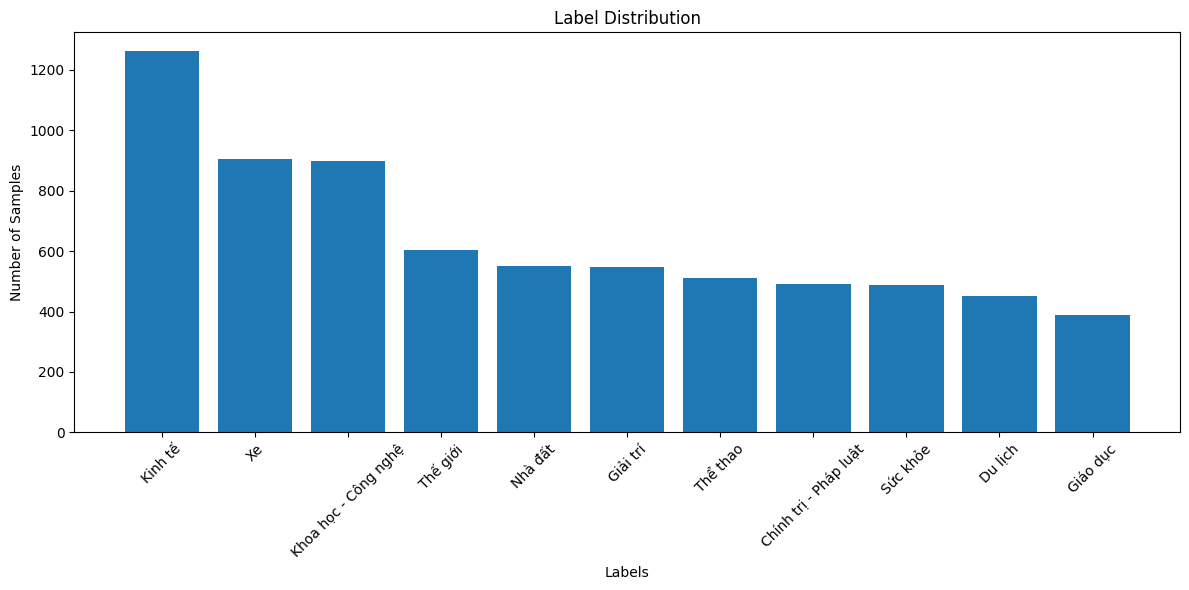

In [63]:
label_counter = Counter()

for labels in df["labels"]:
    label_counter.update(labels)

label_df = pd.DataFrame(
    label_counter.items(),
    columns=["Label", "Count"]
)

# Sắp xếp giảm dần
label_df = label_df.sort_values(
    by="Count",
    ascending=False
)

print(label_df)

# =========================
# VẼ BIỂU ĐỒ
# =========================

plt.figure(figsize=(12, 6))

plt.bar(
    label_df["Label"],
    label_df["Count"]
)

plt.title("Label Distribution")

plt.xlabel("Labels")

plt.ylabel("Number of Samples")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [64]:
df = df.drop(columns=["url"])
df

,title,content,labels,text
0,Con trai ông Bùi Thành Nhơn làm Chủ tịch Novaland,Hội đồng quản trị (HĐQT) Tập đoànNovaland(NVL)...,[Kinh tế],Con trai ông Bùi Thành Nhơn làm Chủ tịch Noval...
1,"Vingroup báo lãi tăng 2,5 lần","Theo báo cáo tài chính quý I, Vingroup ghi nhậ...",[Kinh tế],"Vingroup báo lãi tăng 2,5 lần [SEP] Theo báo c..."
2,Niềm tin tiêu dùng của người Mỹ thấp kỷ lục,Khảo sát công bố ngày 10/4 của Đại học Michiga...,[Kinh tế],Niềm tin tiêu dùng của người Mỹ thấp kỷ lục [S...
3,Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...,"Ngày 4/5, Phó thủ tướng Hồ Quốc Dũng chủ trì c...",[Kinh tế],Phó thủ tướng yêu cầu đàm phán bán 5 triệu tín...
4,"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă...","Ngày 15/5, Liên đoàn Thương mại và Công nghiệp...",[Kinh tế],"TP HCM, Hà Nội tiếp tục không thuộc top đầu nă..."
...,...,...,...,...
6238,Lời khai 'nhiều mâu thuẫn' của kẻ nổ súng Bùi ...,"Chiều 13/5, TAND tỉnh Quảng Ninh xét hỏi Bùi Đ...",[Chính trị - Pháp luật],Lời khai 'nhiều mâu thuẫn' của kẻ nổ súng Bùi ...
6239,23 dự án bất động sản ở Hà Nội bị Thanh tra Ch...,Thông tin được Thanh tra Chính phủ nêu trong t...,[Chính trị - Pháp luật],23 dự án bất động sản ở Hà Nội bị Thanh tra Ch...
6240,Công an làm việc với chủ nhà cầm dao dọa chém ...,"Ngày 28/4, Công an phường Dĩ An, TP HCM đã làm...",[Chính trị - Pháp luật],Công an làm việc với chủ nhà cầm dao dọa chém ...
6241,Những hình phạt tiền khiến người vi phạm e sợ ...,Bộ Luật Hình sự đang được Bộ Công an xây dựng ...,[Chính trị - Pháp luật],Những hình phạt tiền khiến người vi phạm e sợ ...


In [65]:
df.to_csv(
    "cleaned_data.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Done cleaning dataset!")
print("Total samples:", len(df))

Done cleaning dataset!
Total samples: 6243


In [66]:
TARGET_LABEL = "Khoa học - Công nghệ"

# ==========================================
# ĐẾM LABEL ĐI KÈM
# ==========================================

co_occurrence = Counter()

for labels in df["labels"]:

    # nếu có nhãn target
    if TARGET_LABEL in labels:

        for label in labels:

            # bỏ chính nó
            if label != TARGET_LABEL:

                co_occurrence[label] += 1

# ==========================================
# HIỂN THỊ KẾT QUẢ
# ==========================================

print(f"\nCác nhãn thường đi cùng '{TARGET_LABEL}':\n")

for label, count in co_occurrence.most_common():

    print(f"{label}: {count}")


Các nhãn thường đi cùng 'Khoa học - Công nghệ':

Kinh tế: 208
Giáo dục: 37
Sức khỏe: 11
Xe: 1
